In [1]:
import sys
sys.path.append("..")

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from config.config_loader import load_config
from utils.functions import rosenbrock
from utils.optimizers import SGD, RMSProp, Adam
from utils.visualization import plot_rosenbrock_3d, plot_convergence
from scripts.train import run_optimization

In [3]:
SAVE_DIR = "../../report/images/q2_"

In [4]:
config = load_config()
initial_point = (config["initial_point"]["x"], config["initial_point"]["y"])
optimal_point = (config["optimal_point"]["x"], config["optimal_point"]["y"])
gradient_threshold = config["gradient_threshold"]
max_iterations = config["max_iterations"]
learning_rates = config["learning_rates_to_test"]
optimizer_classes = {"SGD": SGD, "RMSProp": RMSProp, "Adam": Adam}

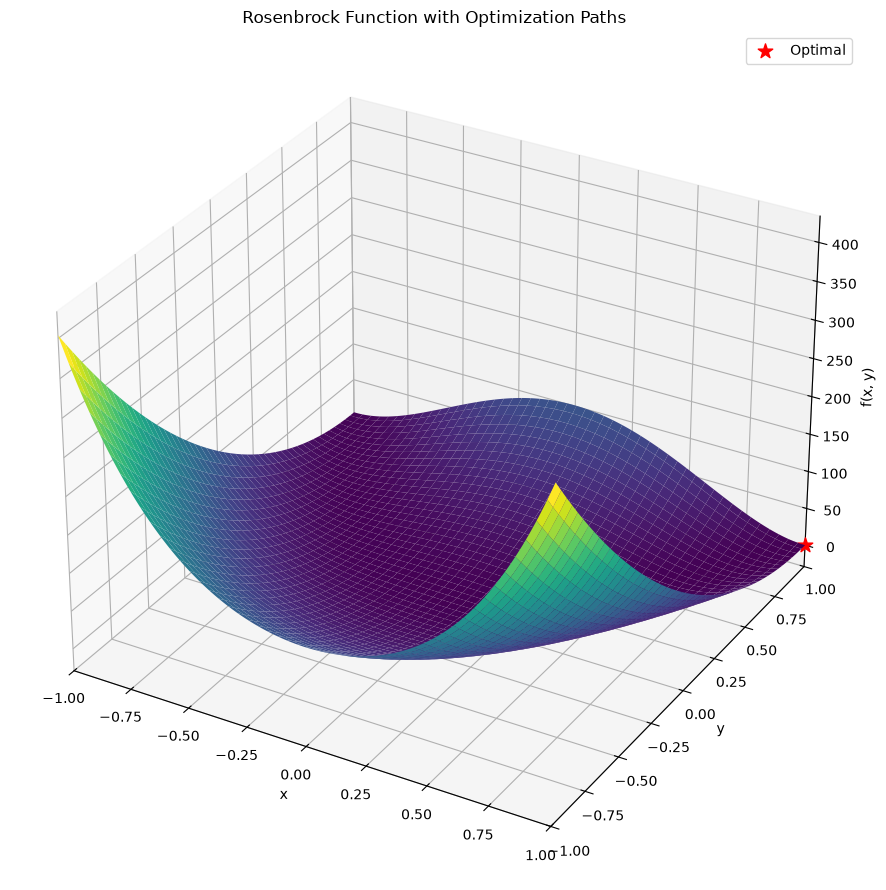

<Figure size 640x480 with 0 Axes>

In [5]:
plot_rosenbrock_3d(
    x_range=(-1, 1),
    y_range=(-1, 1),
    resolution=config["plot"]["resolution"],
    paths=[],
    optimal_point=optimal_point,
)
plt.savefig(SAVE_DIR + "rosenbrock.png")

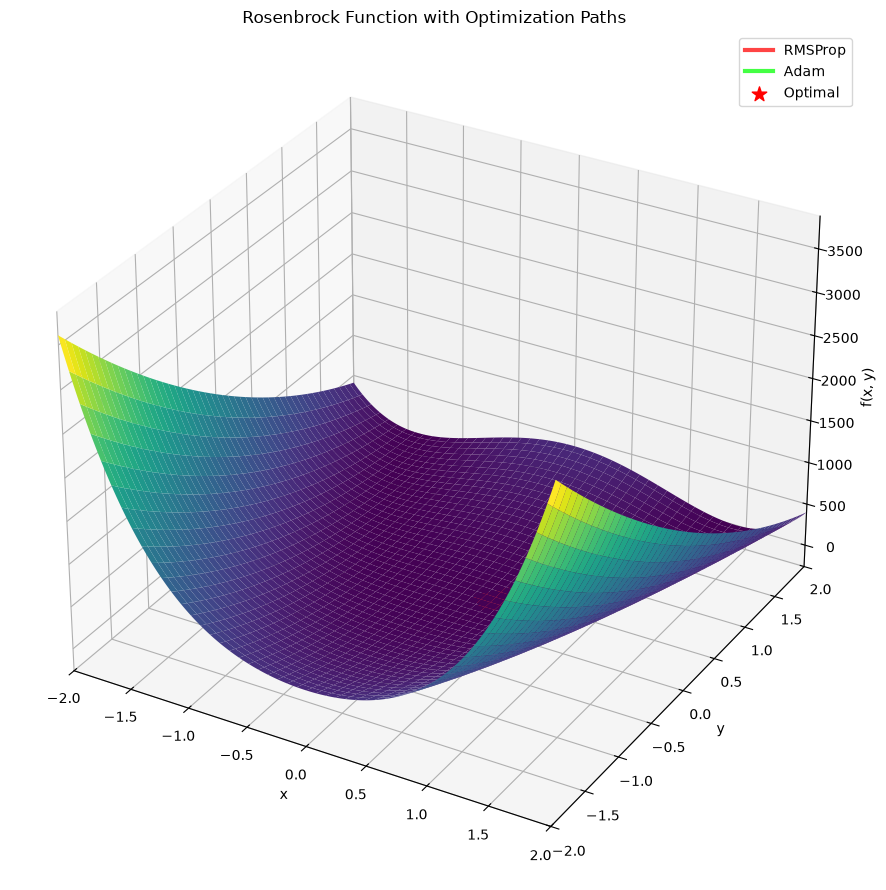

<Figure size 640x480 with 0 Axes>

In [6]:

paths = {}
for name, opt_cls in optimizer_classes.items():
    history = run_optimization(opt_cls, config["learning_rate"], initial_point, optimal_point, gradient_threshold, max_iterations)
    if not history["diverged"]:
        paths[name] = history["path"]

plot_rosenbrock_3d(
    x_range=tuple(config["plot"]["x_range"]),
    y_range=tuple(config["plot"]["y_range"]),
    resolution=config["plot"]["resolution"],
    paths=paths,
    optimal_point=optimal_point,
)
plt.savefig(SAVE_DIR + "paths.png")

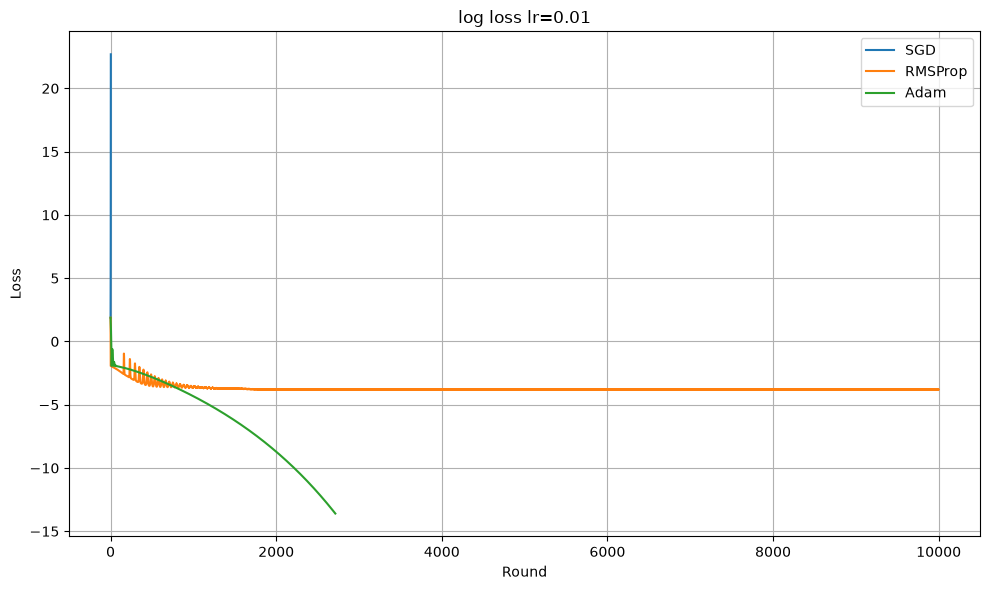

<Figure size 640x480 with 0 Axes>

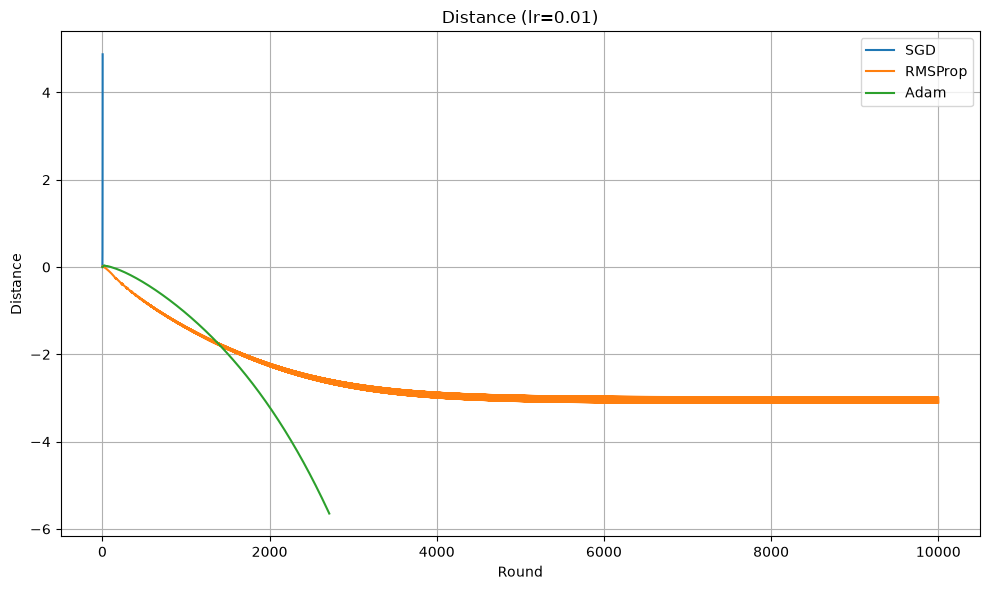

<Figure size 640x480 with 0 Axes>

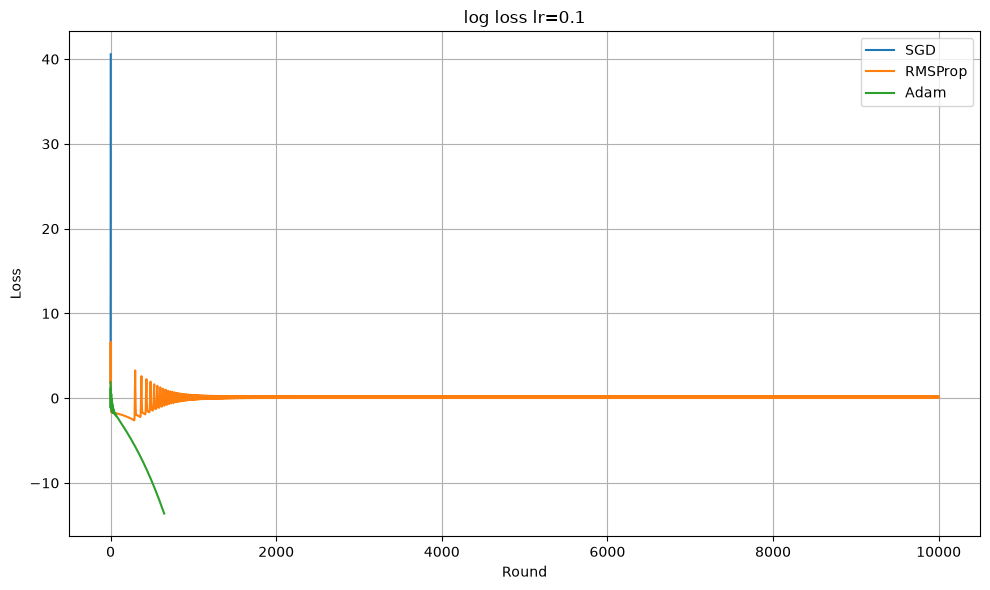

<Figure size 640x480 with 0 Axes>

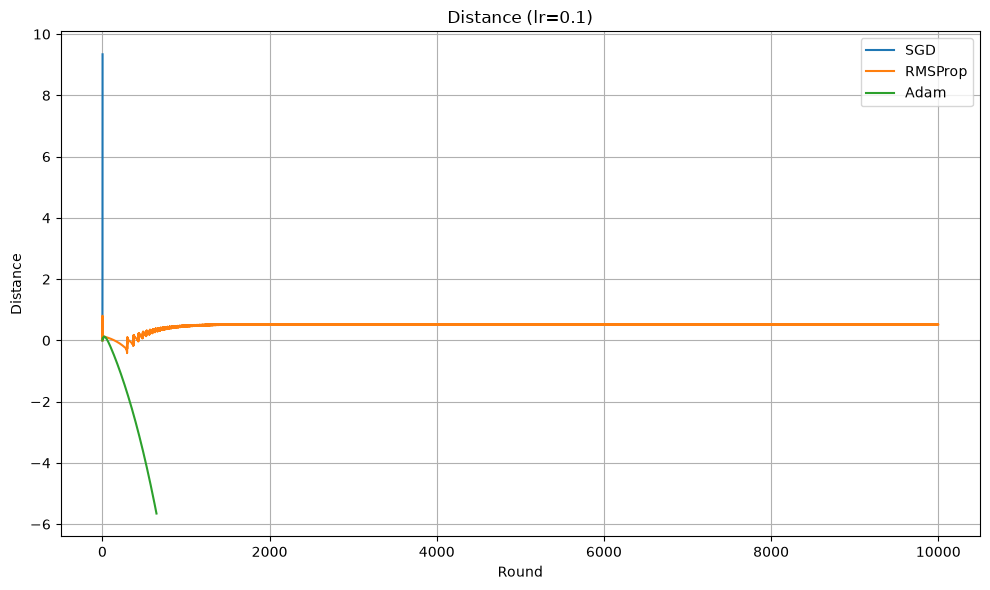

<Figure size 640x480 with 0 Axes>

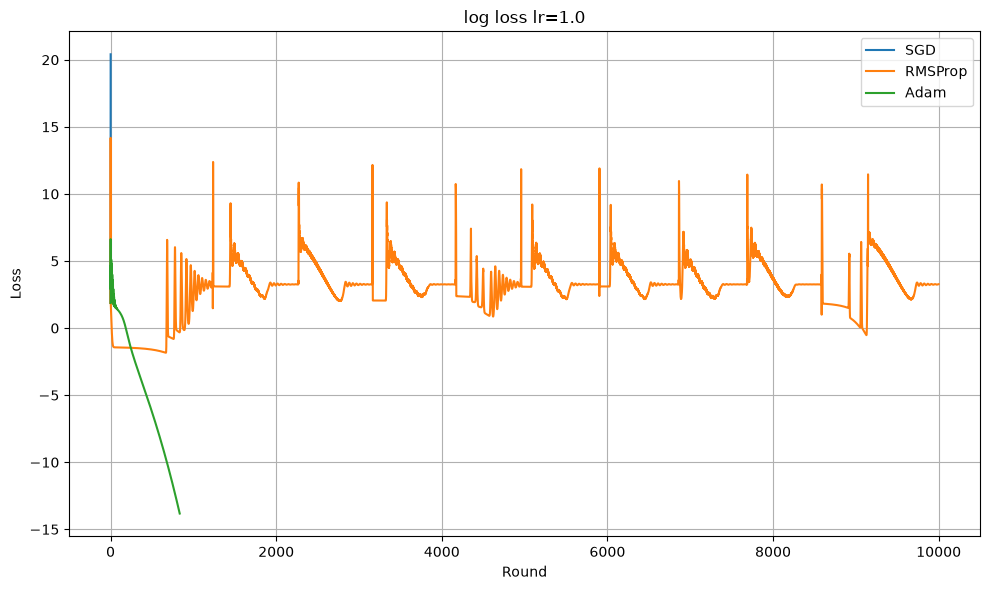

<Figure size 640x480 with 0 Axes>

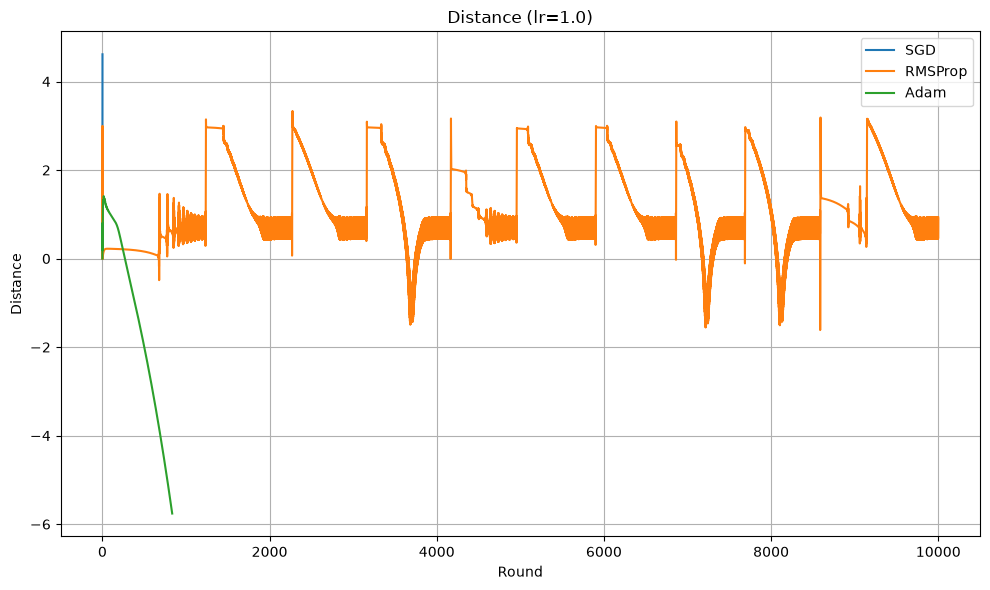

<Figure size 640x480 with 0 Axes>

In [7]:
for lr in learning_rates:
    histories = {}
    for name, opt_cls in optimizer_classes.items():
        histories[name] = run_optimization(opt_cls, lr, initial_point, optimal_point, gradient_threshold, max_iterations)
        h = histories[name]

    plot_convergence(histories, metric="loss", title=f"log loss {lr=}")
    plt.savefig(SAVE_DIR + f"loss{lr}.png")
    plot_convergence(histories, metric="distance", title=f"Distance (lr={lr})")
    plt.savefig(SAVE_DIR + f"distance{lr}.png")